In [8]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [9]:
base_path = "/kaggle/input/datasets/newazfahmir/a-primary-chest-x-ray-dataset-of-normal-bangladesh/A Primary Chest X-ray Dataset of Normal Bangladesh/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia"

train_path = base_path + "/Training"
test_path = base_path + "/Testing"

print(train_path)
print(test_path)

/kaggle/input/datasets/newazfahmir/a-primary-chest-x-ray-dataset-of-normal-bangladesh/A Primary Chest X-ray Dataset of Normal Bangladesh/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia/Training
/kaggle/input/datasets/newazfahmir/a-primary-chest-x-ray-dataset-of-normal-bangladesh/A Primary Chest X-ray Dataset of Normal Bangladesh/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia/Testing


In [10]:
# Verification weather the dataset accessible or not:

print("Training folders:", os.listdir(train_path))
print("Testing folders:", os.listdir(test_path))

print("Training Normal:", len(os.listdir(train_path + "/normal")))
print("Training Pneumonia:", len(os.listdir(train_path + "/pneumonia")))

print("Testing Normal:", len(os.listdir(test_path + "/normal")))
print("Testing Pneumonia:", len(os.listdir(test_path + "/pneumonia")))

Training folders: ['pneumonia', 'normal']
Testing folders: ['pneumonia', 'normal']
Training Normal: 1063
Training Pneumonia: 1050
Testing Normal: 257
Testing Pneumonia: 256


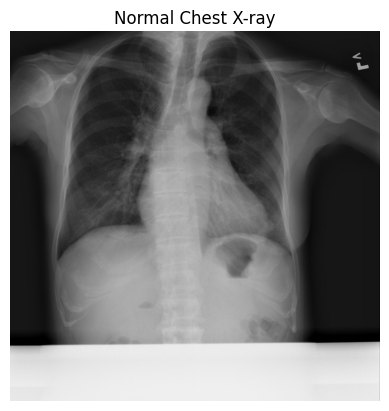

Image size: (1024, 1024)
Image mode: RGB


In [11]:
# Inspecting Sample Images:
sample_path = train_path + "/normal/" + os.listdir(train_path + "/normal")[0]

img = Image.open(sample_path)

plt.imshow(img, cmap="gray")
plt.title("Normal Chest X-ray")
plt.axis("off")
plt.show()

print("Image size:", img.size)
print("Image mode:", img.mode)

In [12]:
# Set: Image Prepossesing size

IMG_SIZE = 224
BATCH_SIZE = 32

print("Target image size:", IMG_SIZE, "x", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Target image size: 224 x 224
Batch size: 32


In [13]:
# Making Traning and validation Dataset

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 2113 files belonging to 2 classes.
Using 1691 files for training.


I0000 00:00:1790086507.423274      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790086507.426606      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 2113 files belonging to 2 classes.
Using 422 files for validation.


In [15]:
# Test Dataset Loading 

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 513 files belonging to 2 classes.


In [16]:
# Class names check

print("Classes:", train_dataset.class_names)

Classes: ['normal', 'pneumonia']


In [19]:
# Loading Dataset again into Raw Formate

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2113 files belonging to 2 classes.
Using 1691 files for training.
Found 2113 files belonging to 2 classes.
Using 422 files for validation.
Found 513 files belonging to 2 classes.


In [20]:
# Checking:
for images, labels in train_dataset.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 255.0


In [21]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [22]:
# Checking: again for normalization
for images, labels in train_dataset.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [23]:
# Data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
])

In [24]:
# Only training Data Augmented

train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0109844].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.049289405..1.0076421].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0150093].


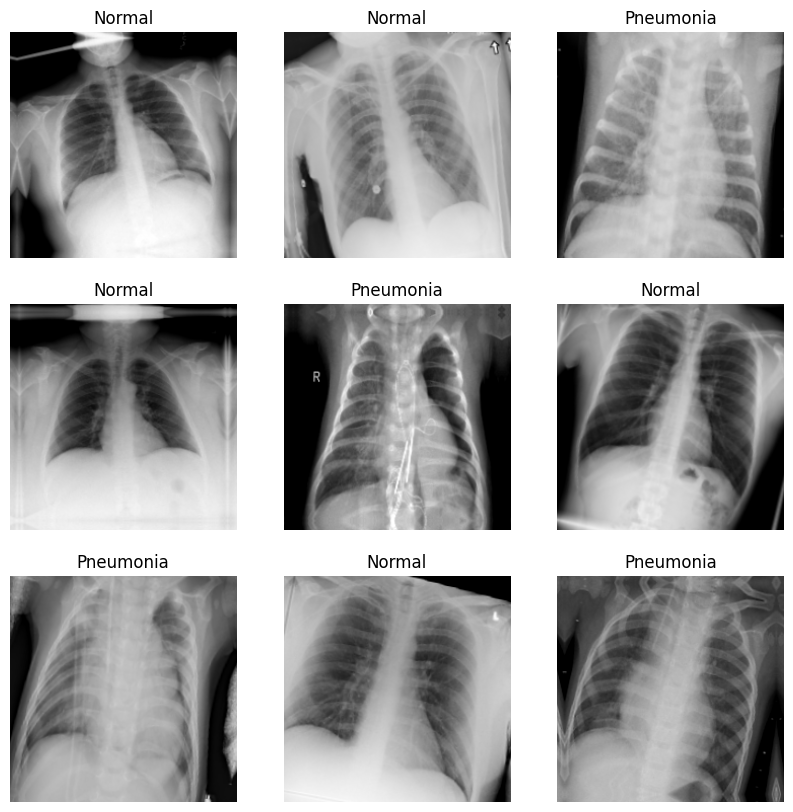

In [25]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy())
        plt.title("Pneumonia" if labels[i].numpy() == 1 else "Normal")
        plt.axis("off")

plt.show()

In [26]:
# Clipping Pixel range 0–1

train_dataset = train_dataset.map(
    lambda x, y: (tf.clip_by_value(x, 0.0, 1.0), y)
)

In [27]:
# Dataset performance optimization

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [28]:
# CNN Architecture Defining:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Compiling the Model:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [30]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50
)

Epoch 1/50


2026-09-22 14:30:15.457515: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 14:30:15.606683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/53 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.4219 - auc: 0.4442 - loss: 0.7003 - precision: 0.4623 - recall: 0.4916 

I0000 00:00:1790087419.150864     328 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


52/53 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.6938 - auc: 0.7569 - loss: 0.5555 - precision: 0.6863 - recall: 0.7468

2026-09-22 14:30:39.579465: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-22 14:30:39.728302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 542ms/step - accuracy: 0.7924 - auc: 0.8730 - loss: 0.4344 - precision: 0.7677 - recall: 0.8193 - val_accuracy: 0.8649 - val_auc: 0.9477 - val_loss: 0.2848 - val_precision: 0.8991 - val_recall: 0.8485
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 23s 427ms/step - accuracy: 0.8788 - auc: 0.9181 - loss: 0.3276 - precision: 0.8404 - recall: 0.9255 - val_accuracy: 0.9218 - val_auc: 0.9661 - val_loss: 0.2241 - val_precision: 0.9057 - val_recall: 0.9567
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 23s 422ms/step - accuracy: 0.8835 - auc: 0.9335 - loss: 0.2925 - precision: 0.8418 - recall: 0.9353 - val_accuracy: 0.9218 - val_auc: 0.9718 - val_loss: 0.2068 - val_precision: 0.9195 - val_recall: 0.9394
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 415ms/step - accuracy: 0.8918 - auc: 0.9439 - loss: 0.2688 - precision: 0.8479 - recall: 0.9463 - val_accuracy: 0.9194 - val_auc: 0.9755 - val_loss: 0.1975 - val_precision: 0.9020 - val_recall: 0.9567
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2

In [31]:
test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test AUC:", test_auc)

17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 291ms/step - accuracy: 0.9201 - auc: 0.9715 - loss: 0.1904 - precision: 0.8746 - recall: 0.9805   
Test Loss: 0.19035007059574127
Test Accuracy: 0.9200779795646667
Test Precision: 0.8745644688606262
Test Recall: 0.98046875
Test AUC: 0.9715086817741394


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step


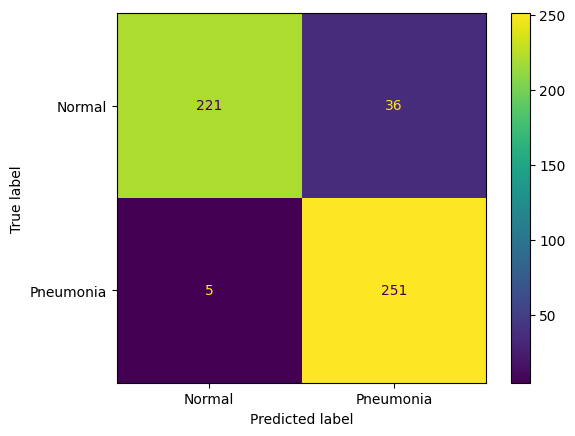

In [32]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.concatenate([y.numpy() for x, y in test_dataset])

y_pred_prob = model.predict(test_dataset)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Pneumonia"]
)

disp.plot()
plt.show()

In [33]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Pneumonia"]
    )
)

              precision    recall  f1-score   support

      Normal       0.98      0.86      0.92       257
   Pneumonia       0.87      0.98      0.92       256

    accuracy                           0.92       513
   macro avg       0.93      0.92      0.92       513
weighted avg       0.93      0.92      0.92       513



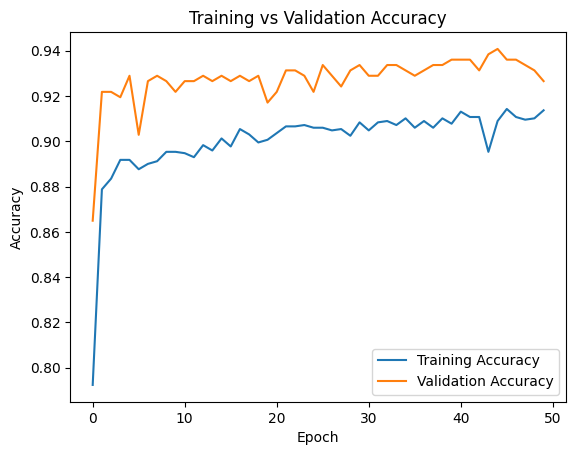

In [34]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

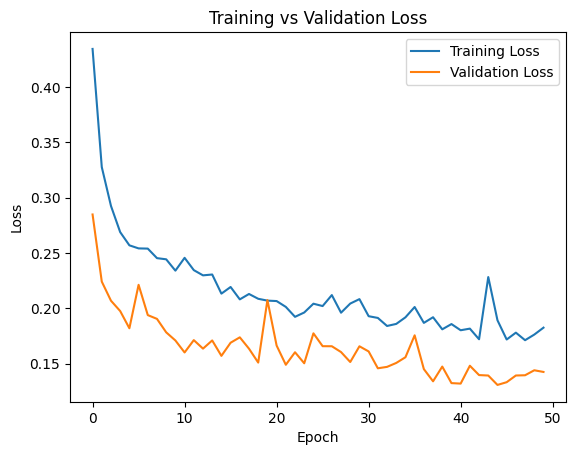

In [35]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [37]:
# Saving The Model:

model.save("/kaggle/working/chest_xray_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.


## Final Results

- **Dataset:** Chest X-ray Images
- **Task:** Binary Image Classification
- **Classes:** Normal and Pneumonia
- **Training Images:** 1691
- **Validation Images:** 422
- **Testing Images:** 513
- **Image Size:** 224 × 224
- **Epochs:** 50

### Test Performance
- **Accuracy:** 92.01%
- **Precision:** 87.46%
- **Recall:** 98.05%
- **AUC:** 97.15%
- **Macro F1-score:** 92%

### Confusion Matrix
- Normal correctly classified: 221
- Normal misclassified as Pneumonia: 36
- Pneumonia misclassified as Normal: 5
- Pneumonia correctly classified: 251